In [129]:
import seaborn as sn 
import matplotlib.pyplot as plt 
import pandas as pd 
import plotly.express as px 
import plotly.graph_objects as go 
import warnings 
warnings.filterwarnings('ignore')

In [130]:
df = pd.read_csv('Food_Delivery_Times.csv')
df

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [132]:
df.shape

(1000, 9)

In [133]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [134]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [135]:
df.fillna('Unknown')

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


<Axes: xlabel='Distance_km', ylabel='Count'>

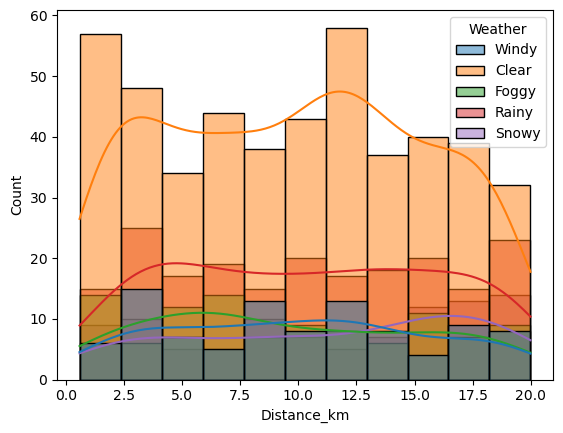

In [136]:
sn.histplot(x = df['Distance_km'] , kde = True , hue = df['Weather' ])

In [137]:
df['Weather'].value_counts()

Weather
Clear    470
Rainy    204
Foggy    103
Snowy     97
Windy     96
Name: count, dtype: int64

In [138]:
df['Courier_Experience_yrs'].value_counts()

Courier_Experience_yrs
6.0    109
9.0    108
1.0    107
8.0    101
2.0     99
4.0     94
7.0     91
0.0     91
5.0     90
3.0     80
Name: count, dtype: int64

In [139]:
cate_cols = ['Weather' , 'Traffic_Level' , 'Time_of_Day']
for cols in cate_cols:
    df[cols] =df[cols].fillna(df[cols].mode()[0])

In [140]:
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].mode())

In [141]:
# df.isnull().sum()

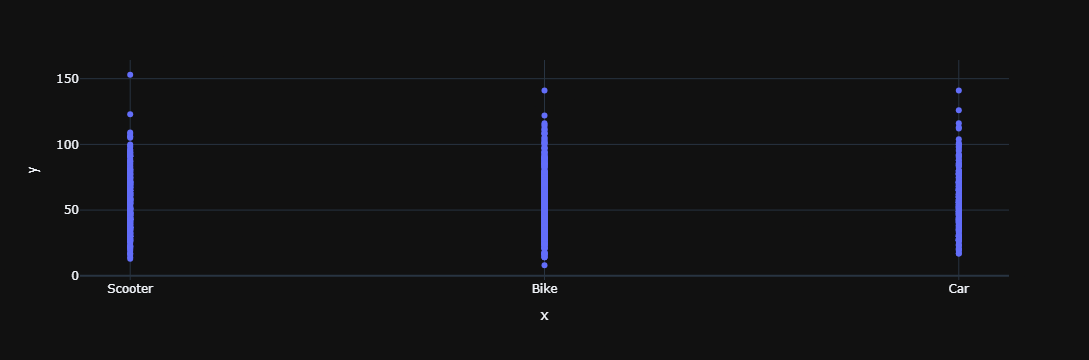

In [142]:
fig = px.scatter(x = df['Vehicle_Type'] , y = df['Delivery_Time_min'])
fig.update_layout(template = 'plotly_dark')
fig.show()

In [143]:
fig = go.Figure(data = [
    go.Scatter3d(
        x = df['Distance_km'],
        y = df['Weather'],
        z = df['Vehicle_Type'],
        
    )
])
fig.update_layout(template = 'plotly_dark')
fig.show()

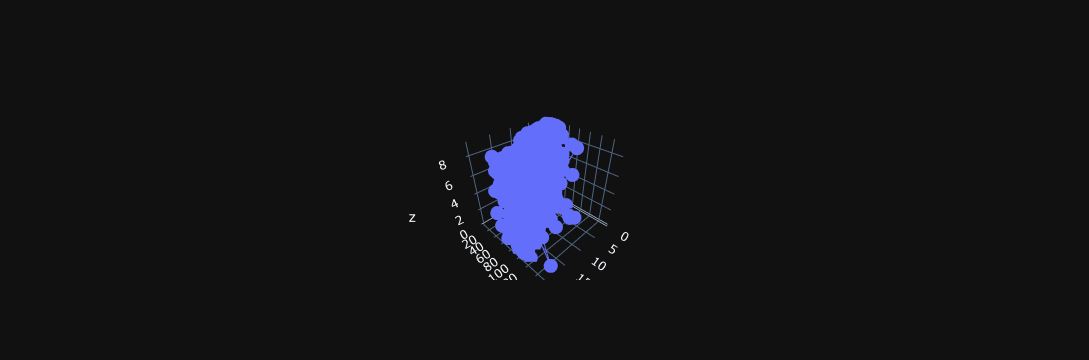

In [144]:
fig = go.Figure(data = [
    go.Scatter3d(
        x = df['Distance_km'],
        y = df['Delivery_Time_min'],
        z = df['Courier_Experience_yrs'],
        
    )
])
fig.update_layout(template = 'plotly_dark')
fig.show()

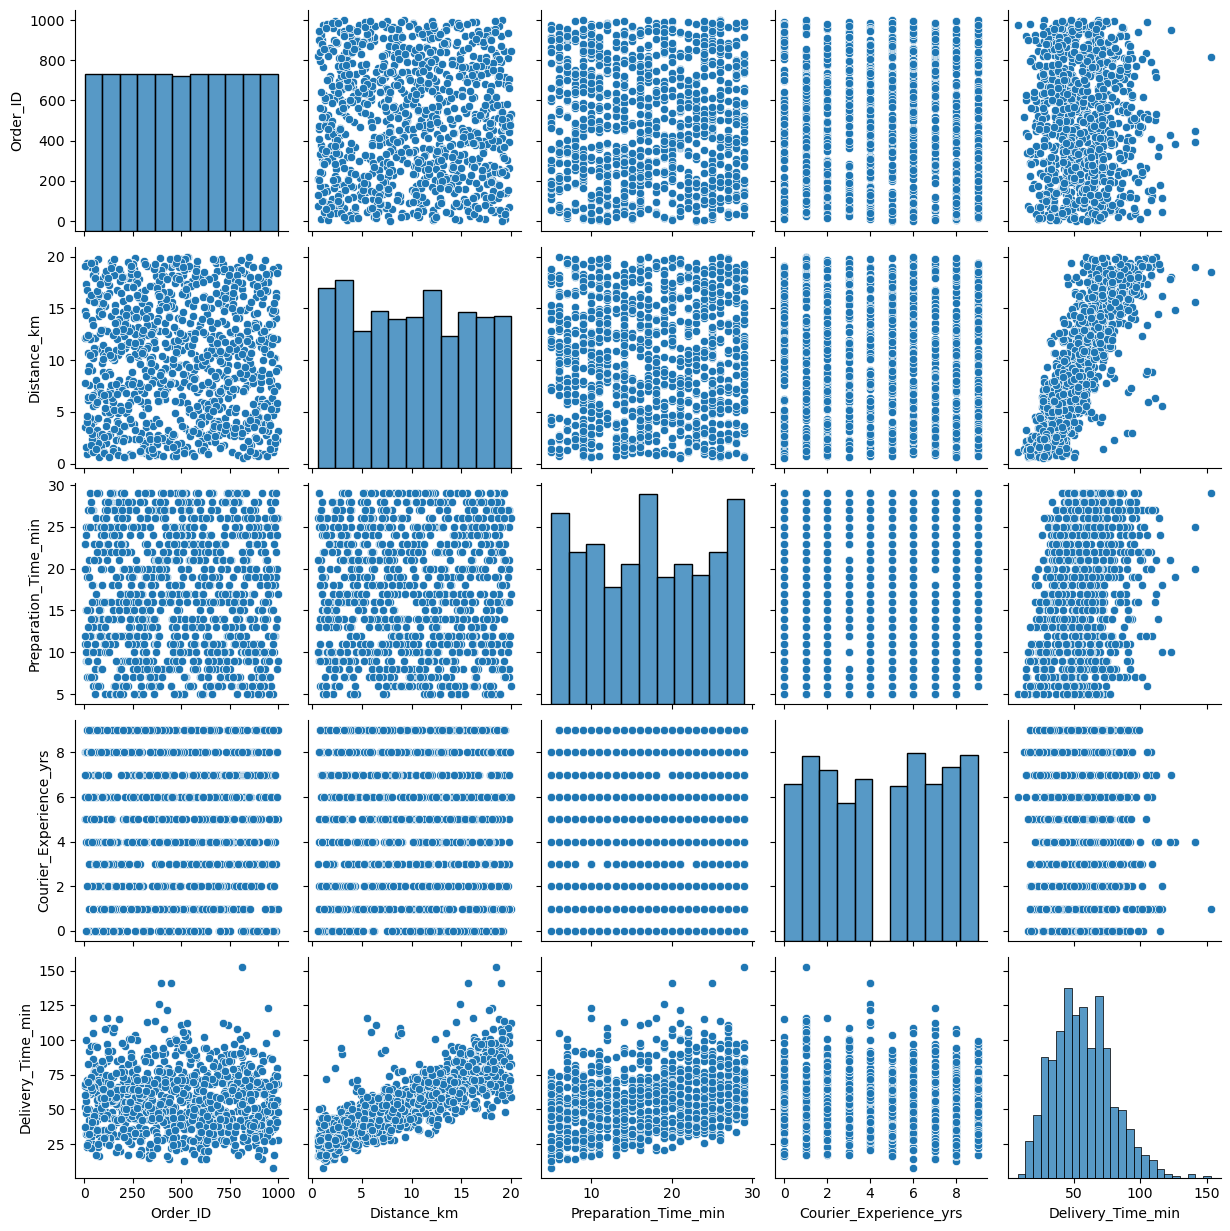

In [145]:
sn.pairplot(df, palette= 'rainbow')

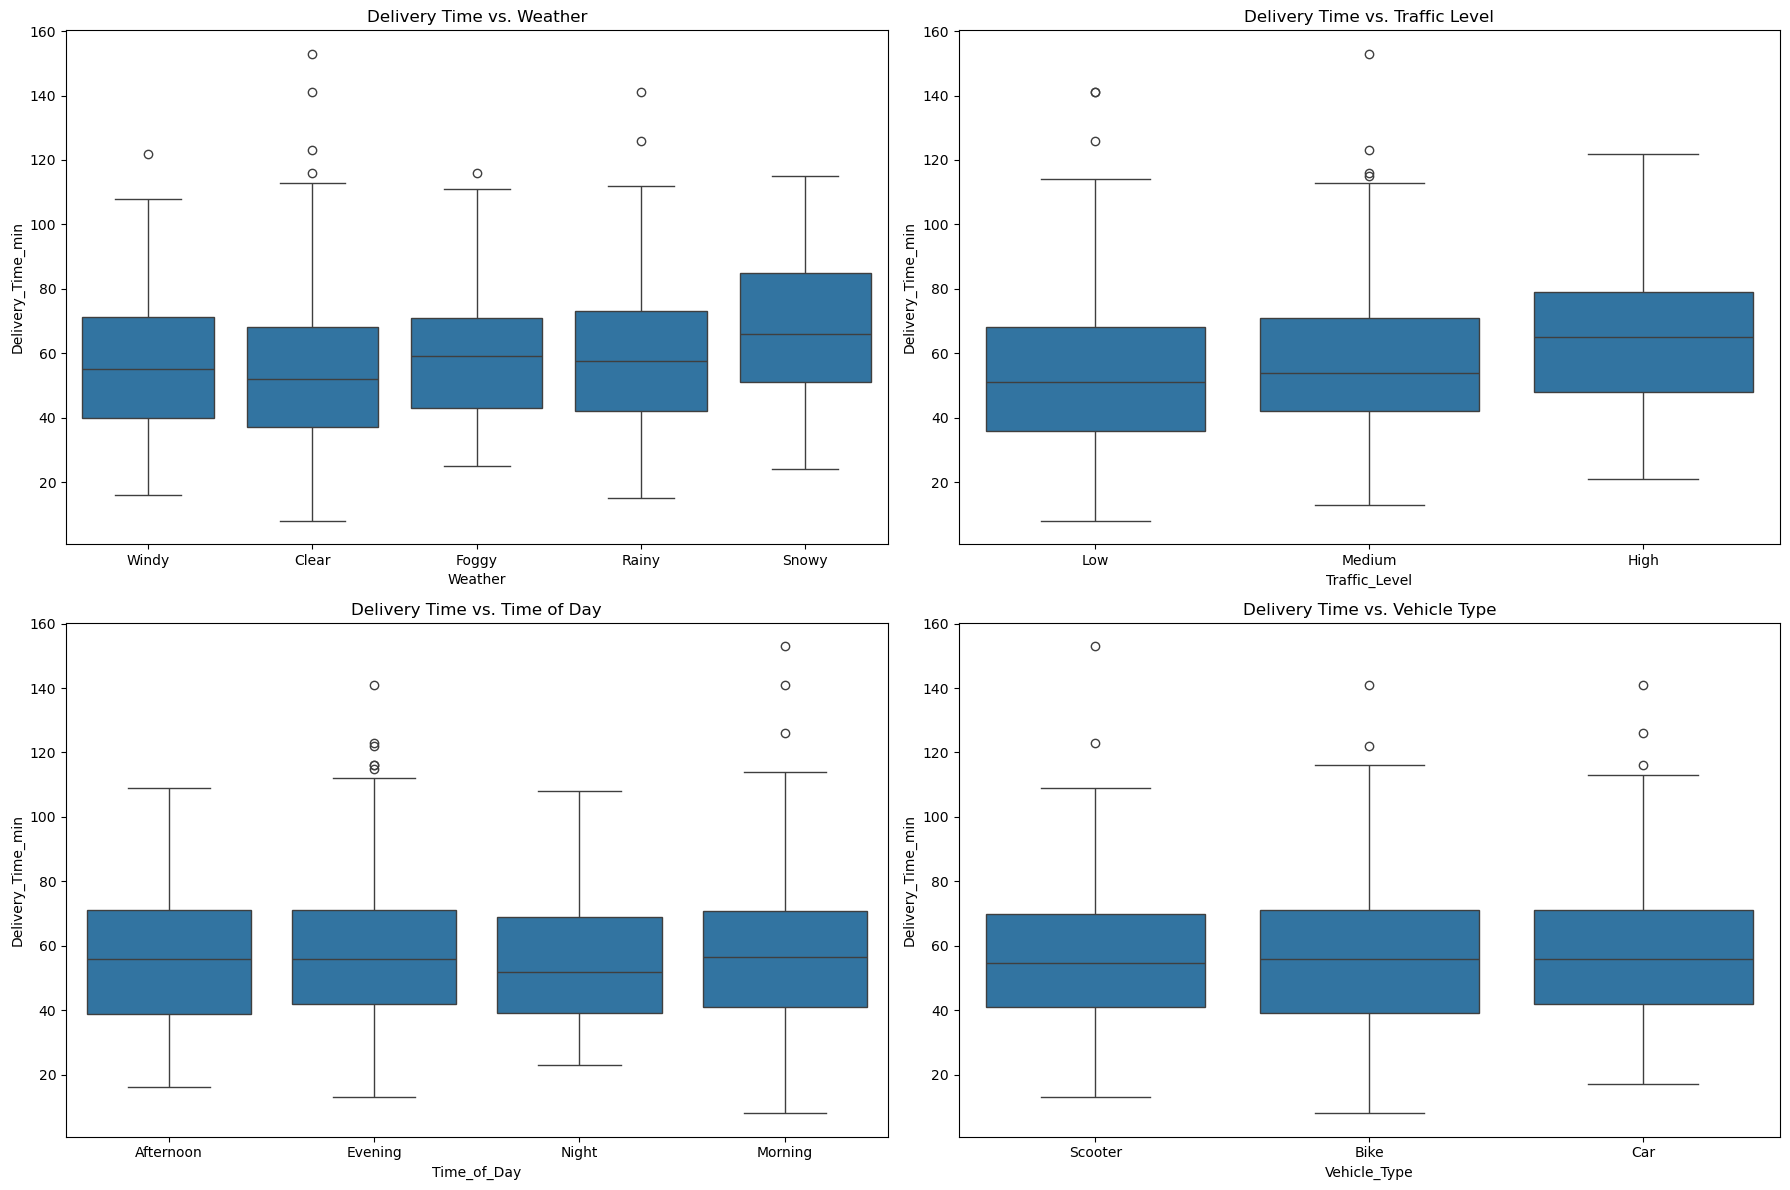

In [146]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))

sn.boxplot(x='Weather', y='Delivery_Time_min', data=df, ax=axes[0, 0])
axes[0, 0].set_title('Delivery Time vs. Weather')

sn.boxplot(x='Traffic_Level', y='Delivery_Time_min', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Delivery Time vs. Traffic Level')

sn.boxplot(x='Time_of_Day', y='Delivery_Time_min', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Delivery Time vs. Time of Day')

sn.boxplot(x='Vehicle_Type', y='Delivery_Time_min', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Delivery Time vs. Vehicle Type')

plt.tight_layout()
plt.show()

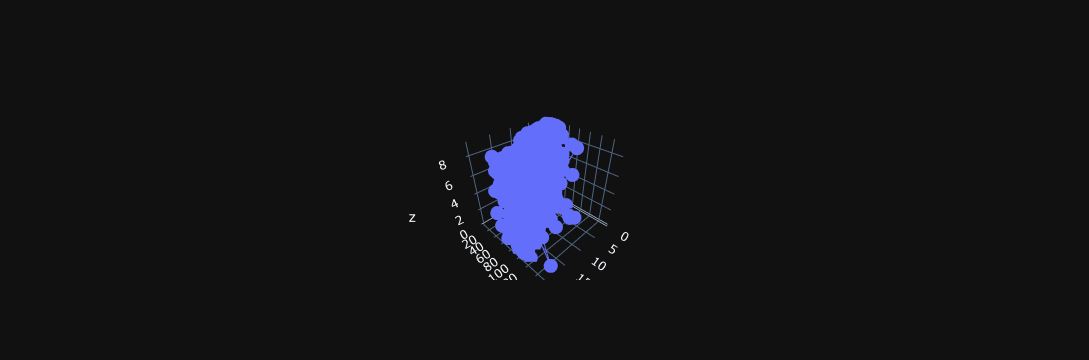

In [147]:
fig = go.Figure(data = [
    go.Scatter3d(
        x = df['Distance_km'],
        y = df['Delivery_Time_min'],
        z = df['Courier_Experience_yrs'],
        
    )
])
fig.update_layout(template = 'plotly_dark')
fig.show()

In [148]:
X = df.drop(['Delivery_Time_min'] , axis = 1)
y = df['Delivery_Time_min']

In [149]:
from sklearn.model_selection import train_test_split

In [150]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [174]:
# First, check what columns are actually available in your DataFrame
print("Available columns:", X_train.columns.tolist())

# Option 1: If the column exists but with a different name, replace with the correct name
# X_train = (X_train['correct_column_name'].fillna(0).astype(int))

# Option 2: If you want to handle the case where the column might not exist
if 'Courier_Experience_yrs' in X_train.columns:
    X_train = (X_train['Courier_Experience_yrs'].fillna(0).astype(int))
else:
    print("Column 'Courier_Experience_yrs' not found. Please check column names.")
    # You can either create a default column or use an alternative column
    # X_train = pd.Series([0] * len(X_train))  # Create default values if needed

AttributeError: 'Series' object has no attribute 'columns'

 # One Hot Encoding

In [151]:
df.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

In [152]:
X_encode = pd.get_dummies(X , columns= ['Weather' , 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type' ], drop_first= True)

In [153]:
display(X_encode.head())

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Car,Vehicle_Type_Scooter
0,522,7.93,12,1.0,False,False,False,True,True,False,False,False,False,False,True
1,738,16.42,20,2.0,False,False,False,False,False,True,True,False,False,False,False
2,741,9.52,28,1.0,True,False,False,False,True,False,False,False,True,False,True
3,661,7.44,5,1.0,False,True,False,False,False,True,False,False,False,False,True
4,412,19.03,16,5.0,False,False,False,False,True,False,False,True,False,False,False


In [154]:
X_encode.head().astype(int)

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Car,Vehicle_Type_Scooter
0,522,7,12,1,0,0,0,1,1,0,0,0,0,0,1
1,738,16,20,2,0,0,0,0,0,1,1,0,0,0,0
2,741,9,28,1,1,0,0,0,1,0,0,0,1,0,1
3,661,7,5,1,0,1,0,0,0,1,0,0,0,0,1
4,412,19,16,5,0,0,0,0,1,0,0,1,0,0,0


# Standard Scaling

In [155]:
from sklearn.preprocessing import StandardScaler

In [156]:
scaler  =  StandardScaler()

nums_cols = [
    'Distance_km',
    'Preparation_Time_min',
    'Courier_Experience_yrs'
]

X_encode[nums_cols] = scaler.fit_transform(X_encode[nums_cols])

In [157]:
X_encode.head().astype(int)

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Car,Vehicle_Type_Scooter
0,522,0,0,-1,0,0,0,1,1,0,0,0,0,0,1
1,738,1,0,0,0,0,0,0,0,1,1,0,0,0,0
2,741,0,1,-1,1,0,0,0,1,0,0,0,1,0,1
3,661,0,-1,-1,0,1,0,0,0,1,0,0,0,0,1
4,412,1,0,0,0,0,0,0,1,0,0,1,0,0,0


In [170]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score 

In [171]:
model = LinearRegression() 

In [172]:
X[['Distance_km', 'Courier_Experience_yrs']] = (X[['Distance_km', 'Courier_Experience_yrs']].fillna(0).astype(int))

In [2]:
# X_train = (X_train['Courier_Experience_yrs'].fillna(0).astype(int))

In [162]:
model = (y_train , y_test)

In [164]:
model = (X_train , y_test)

In [3]:
# y_pred = model.predict(X_test)